In [1]:
from starccato_flow.training.trainer_flow_matching import FlowMatchingTrainer

MPS device found
630763148.816


/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Configs

In [2]:
font_family = "sans-serif"
font_name = "Futura"

In [3]:
trainer = FlowMatchingTrainer(num_epochs=256, parameters=["beta1_IC_b", "omega_0(rad|s)","A(km)", "Ye_c_b", "ra", "dec", "d", "psi"])
trainer.load_model_instance(model_path="../outdir/flow_intrinsic_sky.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['beta1_IC_b', 'omega_0(rad|s)', 'A(km)', 'Ye_c_b', 'ra', 'dec', 'd', 'psi']
Intrinsic params: ['beta1_IC_b', 'Ye_c_b']
Sky params: ['omega_0(rad|s)', 'A(km)', 'ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3, 4, 5, 6, 7]
Final flow parameter dimension: 8

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (4 parameters)
beta1_IC_b          : [    0.000000,     0.215477]
omega_0(rad|s)      : [    0.000000,    15.500000]
A(km)               : [  300.000000, 10000.000000]
Ye_c_b              : [    0.246499,     0.282820]


=== Data Split ===
Total signals: 1764
Training signals: 1588
Validation signals: 176
First 5 training indices: [  28  992 1389  878 1099]
First 5 validation indices: [  32  726  945 1158  389]

sTheta Dataset - Parameter Bounds (4 parameters)
b

### Loss Plots

Loaded 256 training loss entries from ../outdir/flow_intrinsic_sky_losses.csv


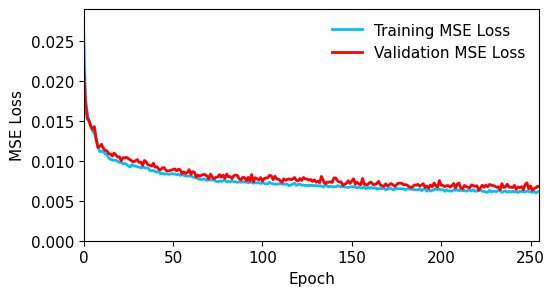

In [4]:
trainer.load_losses(fname="../outdir/flow_intrinsic_sky_losses.csv")
trainer.display_results(fname="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_loss.pdf", background="white", font_family=font_family, font_name=font_name, figsize=(14.5,8), fontsize_title=16, fontsize_tick=11)

### Signal and Corner Plot

In [5]:
trainer.run_parameter_estimation(signal_idx=100, d=5.0, num_samples=3000, fname_signal="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_signal.pdf", fname_posterior="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_posterior.pdf", fname_posterior_sky="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_intrinsic_sky_posterior_sky.pdf", fname_eos_ye="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_ye_eos_posterior.pdf", background="white", font_family=font_family, font_name=font_name, fontsize_tick=11, fontsize_title=11, figsize_corner=(32,32))


hThetaMulti Dataset - Parameter Bounds (8 parameters)
INTRINSIC PARAMETERS:
  beta1_IC_b          : [    0.000000,     0.215477]
  Ye_c_b              : [    0.000000,    15.500000]
  theta_2             : [  300.000000, 10000.000000]
  theta_3             : [    0.246499,     0.282820]

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [    0.000000,     6.283185]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 1
Multi-channel shape: (1, 3, 256)
Parameter dimension: 8
Parameters include theta + sky: [ra, dec, d, polar_angle]

Plot axis ranges (from plotting_defaults PARAMETER_RANGES):
  beta1_IC_b          : (0, 0.25)
  omega_0(rad|s)      : (0, 16)
  A(km)               : (0, 10000)
  Ye_c_b              : (0.24, 0.29)
  ra                  : (0.0, 6.283185307179586)
  dec        

/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/Users/tarineccleston/Desktop/starccato/starccato-flow/src/starccato_flow/plotting/parameters.py:1085: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


### For just Sky Parameters

In [6]:
trainer_sky = FlowMatchingTrainer(num_epochs=256, parameters=["ra", "dec", "d", "psi"])
trainer_sky.load_model_instance(model_path="../outdir/flow_sky.pt")


=== Parameter Extraction Setup ===
Requested parameters: ['ra', 'dec', 'd', 'psi']
Intrinsic params: []
Sky params: ['ra', 'dec', 'd', 'psi']
Extract indices (sequential from hThetaMulti): [0, 1, 2, 3]
Final flow parameter dimension: 4

✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv

sTheta Dataset - Parameter Bounds (0 parameters)


=== Data Split ===
Total signals: 1764
Training signals: 1588
Validation signals: 176
First 5 training indices: [  28  992 1389  878 1099]
First 5 validation indices: [  32  726  945 1158  389]

sTheta Dataset - Parameter Bounds (0 parameters)


sTheta Dataset - Parameter Bounds (0 parameters)


Verifying data alignment:
Number of signals: 1588
Number of parameter sets: 1588
Parameter names: []
First few parameter values:
[]

Verifying data alignment:
Number of signals: 176
Number of parameter sets: 176
Parameter names: []
First few parameter values:
[]



### Losses

Loaded 256 training loss entries from ../outdir/flow_sky_losses.csv


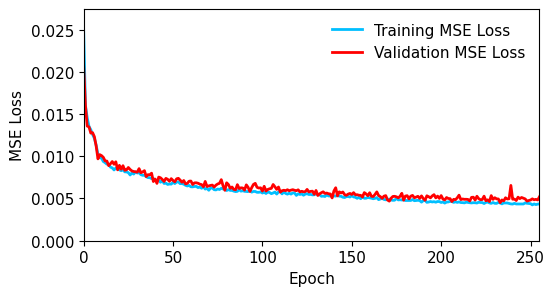

In [7]:
trainer_sky.load_losses(fname="../outdir/flow_sky_losses.csv")
trainer_sky.display_results(fname="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_loss.pdf", background="white", font_family=font_family, font_name=font_name, fontsize_title=11, fontsize_tick=11, figsize=(14.5,8))

### Signal and Corner Plot

In [8]:
trainer_sky.run_parameter_estimation(signal_idx=100, d=5.0, num_samples=3000, fname_signal="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_signal.pdf", fname_posterior="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_posterior.pdf", fname_posterior_sky="../../2025-Statistics-Masters-Thesis/figures/flow-matching/flow_sky_posterior_sky.pdf", background="white", font_family=font_family, font_name=font_name, fontsize_title=11, fontsize_tick=11)


hThetaMulti Dataset - Parameter Bounds (4 parameters)
INTRINSIC PARAMETERS:

EXTRINSIC (SKY) PARAMETERS:
  ra                  : [    0.000000,     6.283185]
  dec                 : [   -1.570796,     1.570796]
  d                   : [    0.000000,    10.000000]
  psi                 : [    0.000000,     3.141593]


=== Multi-Channel Dataset Info ===
Detectors: H1, L1, V1 (3 channels)
Signals per channel: 1
Multi-channel shape: (1, 3, 256)
Parameter dimension: 4
Parameters include theta + sky: [ra, dec, d, polar_angle]

Plot axis ranges (from plotting_defaults PARAMETER_RANGES):
  ra                  : (0.0, 6.283185307179586)
  dec                 : (-1.5707963267948966, 1.5707963267948966)
  d                   : (0, 10)
  psi                 : (0, 3.141592653589793)

Debug: Validating ranges and samples...
  Posterior samples shape: (3000, 4)
  True param shape: (4,)
  Number of ranges: 4
  Number of sample dimensions: 4
  NaN values in samples: 0
  Inf values in samples: 0
  Vali

/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')


### Add, Commit, Push

In [9]:
import subprocess

# Add all files
subprocess.run(["git", "pull"], cwd="../../2025-Statistics-Masters-Thesis")
subprocess.run(["git", "add", "."], cwd="../../2025-Statistics-Masters-Thesis")
# Commit
subprocess.run(["git", "commit", "-m", "Update Plots"], cwd="../../2025-Statistics-Masters-Thesis")
# Push
subprocess.run(["git", "push"], cwd="../../2025-Statistics-Masters-Thesis")

From github.com:the-tarin/2025-Statistics-Masters-Thesis
   c4f2680..3862140  main       -> origin/main


Updating c4f2680..3862140
Fast-forward
 dissertation.tex                                 | 127 +++++++++++++----------
 references_detection_sky_localisation.bib        |   2 +-
 references_gravitational_waves_and_detectors.bib |   2 +-
 references_other.bib                             |   4 +-
 4 files changed, 76 insertions(+), 59 deletions(-)
[main 7666f22] Update Plots
 10 files changed, 0 insertions(+), 0 deletions(-)


To github.com:the-tarin/2025-Statistics-Masters-Thesis.git
   3862140..7666f22  main -> main


CompletedProcess(args=['git', 'push'], returncode=0)